In [24]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance


In [25]:
# Colab: upload the dataset CSV from your computer
from google.colab import files
import io
import pandas as pd

print("Upload the data)")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[fname]))
df.head(3)

Upload the data)


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (2).csv


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


**A Quick EDA**

In [26]:
df.shape, df.columns.tolist(), df['Attrition'].value_counts()

((1470, 35),
 ['Age',
  'Attrition',
  'BusinessTravel',
  'DailyRate',
  'Department',
  'DistanceFromHome',
  'Education',
  'EducationField',
  'EmployeeCount',
  'EmployeeNumber',
  'EnvironmentSatisfaction',
  'Gender',
  'HourlyRate',
  'JobInvolvement',
  'JobLevel',
  'JobRole',
  'JobSatisfaction',
  'MaritalStatus',
  'MonthlyIncome',
  'MonthlyRate',
  'NumCompaniesWorked',
  'Over18',
  'OverTime',
  'PercentSalaryHike',
  'PerformanceRating',
  'RelationshipSatisfaction',
  'StandardHours',
  'StockOptionLevel',
  'TotalWorkingYears',
  'TrainingTimesLastYear',
  'WorkLifeBalance',
  'YearsAtCompany',
  'YearsInCurrentRole',
  'YearsSinceLastPromotion',
  'YearsWithCurrManager'],
 Attrition
 No     1233
 Yes     237
 Name: count, dtype: int64)

In [27]:
# Basic cleaning: check nulls, dtypes
df.info()
df.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


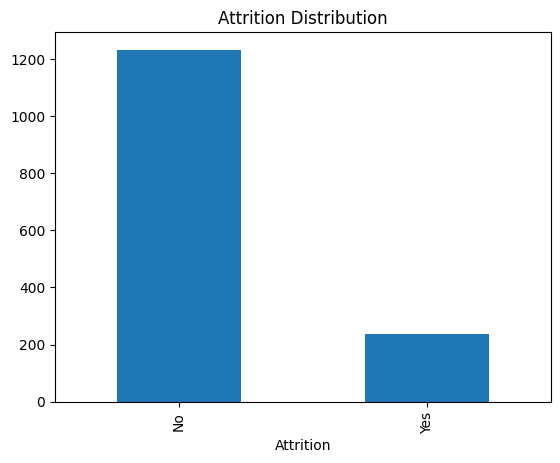

In [28]:
# Target distribution

df['Attrition'].value_counts().plot(kind='bar', title='Attrition Distribution')
plt.show()


Train/Test Split & Preprocessing

In [31]:
# Separate features/target
TARGET_COL = 'Attrition'
y = (df[TARGET_COL] == 'Yes').astype(int)  # convert Yes/No -> 1/0
X = df.drop(columns=[TARGET_COL])

# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Some identifier-like columns you may want to drop (keep it simple/transparent)
drop_like = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
drop_cols = [c for c in drop_like if c in X.columns]
X = X.drop(columns=drop_cols)
num_cols = [c for c in num_cols if c not in drop_cols]
cat_cols = [c for c in cat_cols if c not in drop_cols]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ]
)


Now defining Models

In [32]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=None),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}


Training & Evaluation

In [30]:

def evaluate(model_name, pipe, X_test, y_test):
    y_prob = pipe.predict_proba(X_test)[:,1] if hasattr(pipe, "predict_proba") else None
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    print(f"=== {model_name} ===")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1:        {f1:.3f}")
    print(f"ROC-AUC:   {roc:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    plt.imshow(cm, cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.colorbar()
    plt.xticks([0,1], ['No','Yes'])
    plt.yticks([0,1], ['No','Yes'])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()

    return {"acc": acc, "prec": prec, "rec": rec, "f1": f1, "roc": roc}


Fit, Compare, Pick Best

=== LogisticRegression ===
Accuracy:  0.861
Precision: 0.615
Recall:    0.340
F1:        0.438
ROC-AUC:   0.812

Classification Report:
              precision    recall  f1-score   support

           0      0.884     0.960     0.920       247
           1      0.615     0.340     0.438        47

    accuracy                          0.861       294
   macro avg      0.750     0.650     0.679       294
weighted avg      0.841     0.861     0.843       294



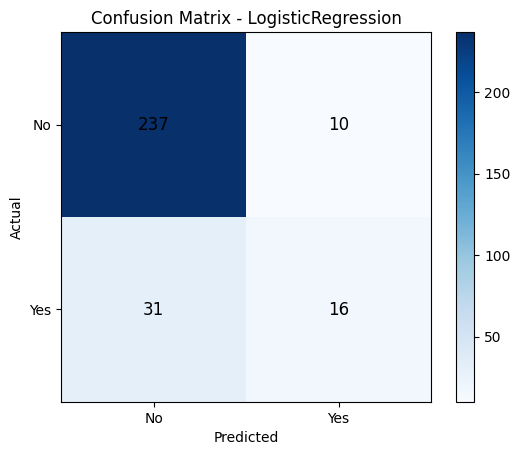

=== RandomForest ===
Accuracy:  0.850
Precision: 0.636
Recall:    0.149
F1:        0.241
ROC-AUC:   0.801

Classification Report:
              precision    recall  f1-score   support

           0      0.859     0.984     0.917       247
           1      0.636     0.149     0.241        47

    accuracy                          0.850       294
   macro avg      0.748     0.566     0.579       294
weighted avg      0.823     0.850     0.809       294



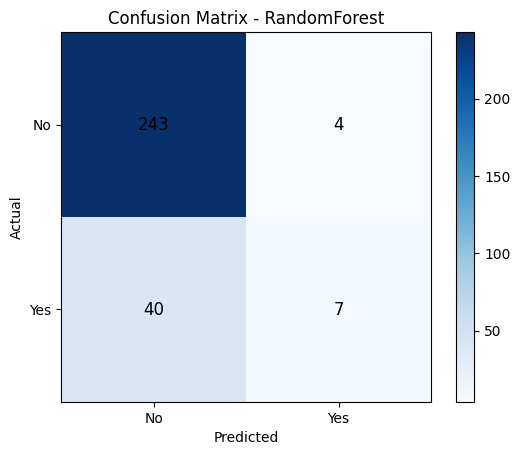

=== GradientBoosting ===
Accuracy:  0.861
Precision: 0.714
Recall:    0.213
F1:        0.328
ROC-AUC:   0.805

Classification Report:
              precision    recall  f1-score   support

           0      0.868     0.984     0.922       247
           1      0.714     0.213     0.328        47

    accuracy                          0.861       294
   macro avg      0.791     0.598     0.625       294
weighted avg      0.843     0.861     0.827       294



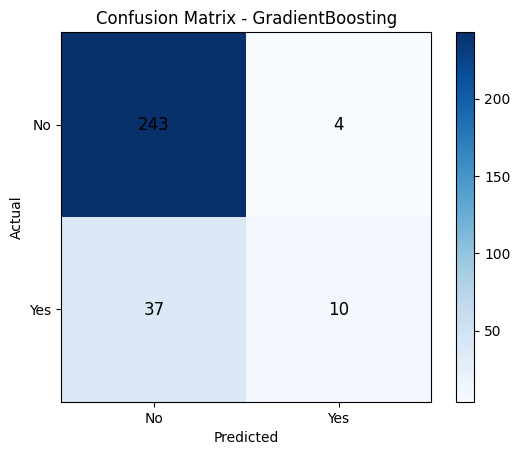

Best model: LogisticRegression with scores: {'acc': 0.8605442176870748, 'prec': 0.6153846153846154, 'rec': 0.3404255319148936, 'f1': 0.4383561643835616, 'roc': np.float64(0.8115255405289)}


In [22]:

scores = {}
fitted = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', clone(model))])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    scores[name] = evaluate(name, pipe, X_test, y_test)

# Pick the best by ROC-AUC (fallback to F1 if NaN)
def score_key(s):
    return (s['roc'] if not np.isnan(s['roc']) else 0.0, s['f1'])

best_name = max(scores, key=lambda k: score_key(scores[k]))
best_pipe = fitted[best_name]
print("Best model:", best_name, "with scores:", scores[best_name])


Permutation Importance (Top Drivers)

,feature,importance_mean,importance_std
18,f18,0.045918,0.011204
28,f28,0.009524,0.008020
13,f13,0.005442,0.009152
17,f17,0.002721,0.006418
25,f25,0.002381,0.005056
20,f20,0.000340,0.002381
9,f9,0.000000,0.000000
5,f5,0.000000,0.000000
16,f16,0.000000,0.000000
15,f15,-0.000340,0.002381


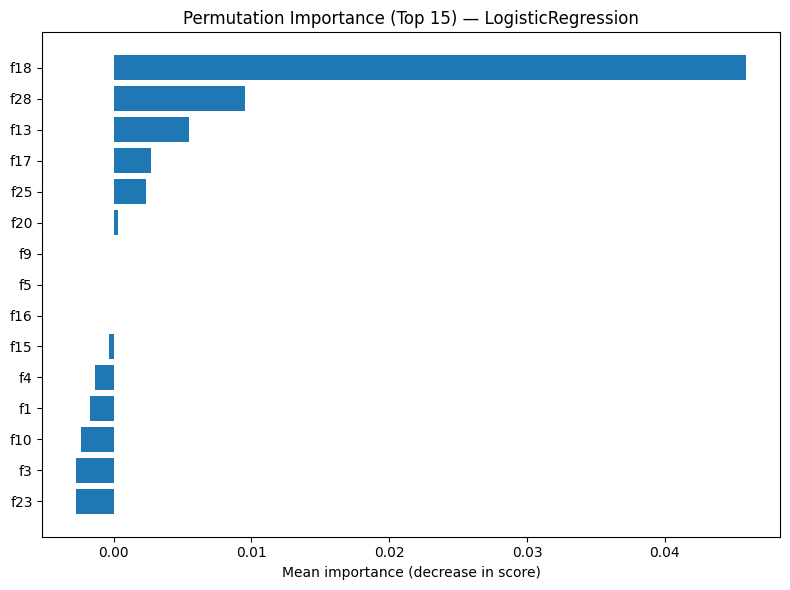

n_perm: 30 | len(feature_names): 30


In [37]:
# Robust permutation importance + aligned feature names + plot (works across sklearn versions)

# 1) Compute permutation importance on the full pipeline (X in original feature space)
r = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

# 2) Build a bullet-proof list of post-preprocessing feature names
feature_names = None
prep = best_pipe.named_steps['prep']

# Try direct export from the ColumnTransformer (preferred, exact ordering)
try:
    feature_names = prep.get_feature_names_out().tolist()
except Exception:
    feature_names = None

# If that didn't work, try to get names from the actual transformed DataFrame (if set_output('pandas') was used)
if feature_names is None:
    try:
        Xt_all = prep.transform(X_test)
        if hasattr(Xt_all, "columns"):
            feature_names = Xt_all.columns.to_list()
    except Exception:
        feature_names = None

# Otherwise, reconstruct from the numeric + OHE transformers
if feature_names is None:
    try:
        num_transformer = prep.named_transformers_['num']
        cat_transformer = prep.named_transformers_['cat']
    except Exception:
        num_transformer = None
        cat_transformer = None

    # Numeric names
    num_names = []
    if num_transformer is not None:
        try:
            num_names = list(num_transformer.get_feature_names_out(num_cols))
        except Exception:
            # Fallback: numeric transformer often just scales; use original names (optionally prefixed)
            num_names = [f"num__{c}" for c in num_cols]

    # Categorical names
    cat_names = []
    if cat_transformer is not None:
        try:
            cat_names = list(cat_transformer.get_feature_names_out(cat_cols))
        except Exception:
            try:
                cat_names = list(cat_transformer.get_feature_names(cat_cols))  # older API
            except Exception:
                # Ultimate fallback: derive count from categories_
                if hasattr(cat_transformer, "categories_"):
                    cat_names = []
                    for c, cats in zip(cat_cols, cat_transformer.categories_):
                        cat_names.extend([f"{c}_{str(v)}" for v in cats])

    feature_names = num_names + cat_names

# Final sanity check: if lengths still mismatch, fall back to positional names using the true transformed width
n_perm = r.importances_mean.shape[0]
if len(feature_names) != n_perm:
    try:
        Xt = prep.transform(X_test)
        n_cols = Xt.shape[1]
        if n_cols != n_perm:
            # If even this differs, trust permutation_importance length
            feature_names = [f"f{i}" for i in range(n_perm)]
        else:
            feature_names = [f"f{i}" for i in range(n_cols)] if not hasattr(Xt, "columns") else Xt.columns.to_list()
    except Exception:
        feature_names = [f"f{i}" for i in range(n_perm)]

# 3) Build importances DataFrame (lengths now guaranteed to match)
importances = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std,
}).sort_values("importance_mean", ascending=False)

# 4) Show top 15 + plot
display(importances.head(15))
topk = importances.head(15)
plt.figure(figsize=(8, 6))
plt.barh(topk["feature"][::-1], topk["importance_mean"][::-1])
try:
    model_name = type(best_pipe.named_steps['model']).__name__
except Exception:
    model_name = "Model"
plt.title(f"Permutation Importance (Top 15) — {model_name}")
plt.xlabel("Mean importance (decrease in score)")
plt.tight_layout()
plt.show()

# 5) Optional: print quick diagnostics
print("n_perm:", n_perm, "| len(feature_names):", len(feature_names))

=== Metrics @ 0.5 ===
    accuracy: 0.861
   precision: 0.615
      recall: 0.340
          f1: 0.438
     roc_auc: 0.812
avg_precision: 0.584

=== Metrics @ best-F1 threshold ===
   threshold: 0.251
    accuracy: 0.840
   precision: 0.500
      recall: 0.617
          f1: 0.552

Classification Report (@best-F1):
              precision    recall  f1-score   support

           0      0.924     0.883     0.903       247
           1      0.500     0.617     0.552        47

    accuracy                          0.840       294
   macro avg      0.712     0.750     0.728       294
weighted avg      0.856     0.840     0.847       294



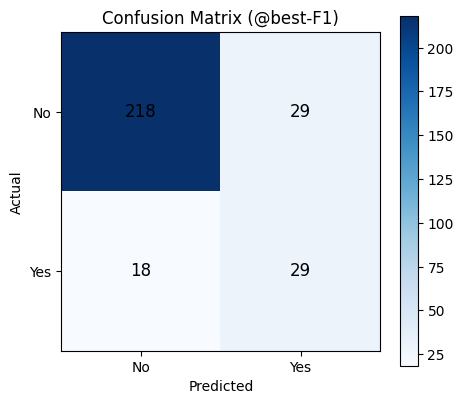

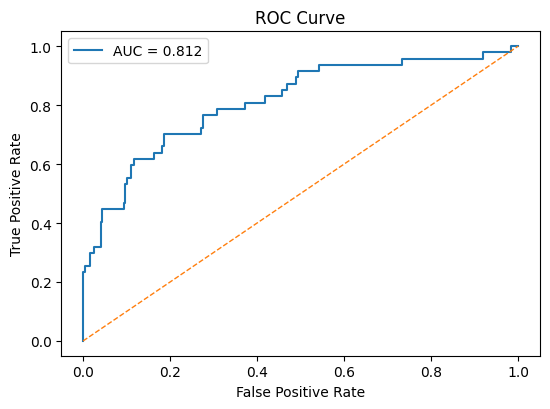

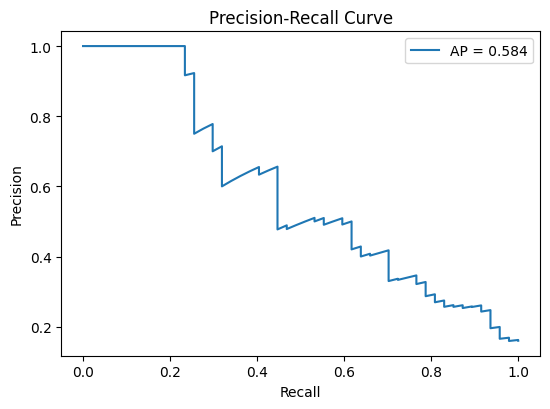

Saved model -> best_attrition_model.joblib
Saved importances -> permutation_importances.csv
Saved metrics -> metrics.json

Demo inference on one row:
Pred: 0 | Prob(Attrition=Yes): 0.077


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1061,24,Non-Travel,830,Sales,13,2,Life Sciences,4,Female,78,...,3,3,1,1,2,3,1,0,0,0


In [38]:
# Finalize project — curves, threshold tuning, metrics, save artifacts, and inference helper
import json, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix
)

# --- 1) Scores at default 0.5 and threshold tuning by best F1 ---
# NOTE: works if your model supports predict_proba
y_prob = best_pipe.predict_proba(X_test)[:, 1]
y_pred_05 = (y_prob >= 0.5).astype(int)

# Default 0.5 metrics
metrics_05 = dict(
    accuracy=accuracy_score(y_test, y_pred_05),
    precision=precision_score(y_test, y_pred_05, zero_division=0),
    recall=recall_score(y_test, y_pred_05, zero_division=0),
    f1=f1_score(y_test, y_pred_05, zero_division=0),
    roc_auc=roc_auc_score(y_test, y_prob),
    avg_precision=average_precision_score(y_test, y_prob)
)

# Threshold sweep to maximize F1
prec, rec, thr = precision_recall_curve(y_test, y_prob)
f1s = (2 * prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s[:-1])  # last point corresponds to threshold=1 (no predictions)
best_thr = thr[best_idx]
y_pred_bt = (y_prob >= best_thr).astype(int)

metrics_bt = dict(
    threshold=float(best_thr),
    accuracy=accuracy_score(y_test, y_pred_bt),
    precision=precision_score(y_test, y_pred_bt, zero_division=0),
    recall=recall_score(y_test, y_pred_bt, zero_division=0),
    f1=f1_score(y_test, y_pred_bt, zero_division=0)
)

print("=== Metrics @ 0.5 ===")
for k, v in metrics_05.items(): print(f"{k:>12}: {v:.3f}")
print("\n=== Metrics @ best-F1 threshold ===")
for k, v in metrics_bt.items():
    if isinstance(v, float): print(f"{k:>12}: {v:.3f}")
    else: print(f"{k:>12}: {v}")

print("\nClassification Report (@best-F1):")
print(classification_report(y_test, y_pred_bt, digits=3, zero_division=0))

# Confusion matrix (@best-F1)
cm = confusion_matrix(y_test, y_pred_bt)
plt.figure(figsize=(4.8,4.2))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (@best-F1)')
plt.colorbar()
plt.xticks([0,1], ['No','Yes'])
plt.yticks([0,1], ['No','Yes'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# --- 2) Curves (ROC + PR) ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(5.6,4.2))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--', linewidth=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(); plt.tight_layout(); plt.show()

ap = average_precision_score(y_test, y_prob)
plt.figure(figsize=(5.6,4.2))
plt.plot(rec, prec, label=f"AP = {ap:.3f}")
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(); plt.tight_layout(); plt.show()

# --- 3) Save artifacts: model, importances, and metrics ---
joblib.dump(best_pipe, 'best_attrition_model.joblib')
print("Saved model -> best_attrition_model.joblib")

# 'importances' should already exist from the previous cell; guard just in case
if 'importances' in globals() and isinstance(importances, pd.DataFrame):
    importances.to_csv('permutation_importances.csv', index=False)
    print("Saved importances -> permutation_importances.csv")

artifacts = {
    "metrics_at_0p5": metrics_05,
    "metrics_at_best_f1": metrics_bt,
    "roc_auc": float(roc_auc),
    "avg_precision": float(ap),
}
with open('metrics.json', 'w') as f:
    json.dump(artifacts, f, indent=2)
print("Saved metrics -> metrics.json")

# --- 4) Tiny inference helper you can demo in README ---
# Build a single-row example from X_test (keeps correct schema)
_example = X_test.iloc[[0]].copy()

def predict_attrition(df_row_or_rows, threshold=best_thr):
    """
    df_row_or_rows: pandas DataFrame with SAME columns as your original X (pre-preprocessing).
    Returns: (preds, proba) where preds are 0/1 using the chosen threshold.
    """
    probs = best_pipe.predict_proba(df_row_or_rows)[:, 1]
    preds = (probs >= threshold).astype(int)
    return preds, probs

preds, probs = predict_attrition(_example)
print("\nDemo inference on one row:")
print("Pred:", int(preds[0]), "| Prob(Attrition=Yes):", round(float(probs[0]), 3))
_example


In [39]:
# Save a schema for the Streamlit UI
import json, numpy as np

schema = {
    "num_cols": [c for c in X_train.select_dtypes(include=["int64","float64"]).columns],
    "cat_cols": [c for c in X_train.select_dtypes(include=["object"]).columns],
    "categories": {
        c: sorted([str(v) for v in X_train[c].dropna().unique().tolist()])
        for c in X_train.select_dtypes(include=["object"]).columns
    },
    "defaults": {
        # sensible defaults: numeric median, categorical mode (falls back to first option)
        **{c: float(X_train[c].median()) for c in X_train.select_dtypes(include=["int64","float64"]).columns},
        **{
            c: (
                str(X_train[c].mode(dropna=True).iloc[0])
                if not X_train[c].mode(dropna=True).empty
                else (sorted([str(v) for v in X_train[c].dropna().unique().tolist()])[:1] + [""])[0]
            )
            for c in X_train.select_dtypes(include=["object"]).columns
        }
    }
}

with open("schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("Wrote schema.json")


Wrote schema.json


In [36]:
import json

artifacts = {
    "metrics_at_0p5": metrics_05,
    "metrics_at_best_f1": metrics_bt,
    "roc_auc": float(roc_auc),
    "avg_precision": float(ap),
}
with open('metrics.json', 'w') as f:
    json.dump(artifacts, f, indent=2)
print("metrics.json saved")

metrics.json saved


In [40]:

import json

schema = {
    "num_cols": [c for c in X_train.select_dtypes(include=["int64","float64"]).columns],
    "cat_cols": [c for c in X_train.select_dtypes(include=["object"]).columns],
    "categories": {
        c: sorted([str(v) for v in X_train[c].dropna().unique().tolist()])
        for c in X_train.select_dtypes(include=["object"]).columns
    },
    "defaults": {
        **{c: float(X_train[c].median()) for c in X_train.select_dtypes(include=["int64","float64"]).columns},
        **{
            c: (
                str(X_train[c].mode(dropna=True).iloc[0])
                if not X_train[c].mode(dropna=True).empty
                else (sorted([str(v) for v in X_train[c].dropna().unique().tolist()])[:1] + [""])[0]
            )
            for c in X_train.select_dtypes(include=["object"]).columns
        }
    }
}
with open("schema.json", "w") as f:
    json.dump(schema, f, indent=2)
print("schema.json saved")


schema.json saved


In [43]:
from google.colab import files
files.download("best_attrition_model.joblib")
files.download("schema.json")
files.download("metrics.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>